In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

data = pd.read_csv("spambase.data", header=None)


X = data.iloc[:, :-1]
y = data.iloc[:, -1]

# 75/25 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [3]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[650  26]
 [ 55 420]]


In [4]:
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print("Accuracy:", accuracy)
print("Error:", error)

Accuracy: 0.9296264118158123
Error: 0.07037358818418771


In [5]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.9417040358744395
Recall: 0.8842105263157894
F1: 0.9120521172638436


In [6]:
coefficients = pd.Series(model.coef_[0])

print(coefficients.sort_values(ascending=False).head(10))
print(coefficients.sort_values().head(10))

52    3.584100
22    2.130495
6     2.112608
14    1.472048
53    1.129413
15    1.005696
35    0.959858
19    0.933206
16    0.892482
3     0.757097
dtype: float64
26   -4.233839
24   -1.804922
43   -1.801782
47   -1.757691
41   -1.545358
45   -1.369376
40   -1.253397
28   -1.184745
32   -1.178726
48   -1.005327
dtype: float64


In [7]:
import numpy as np

probs = model.predict_proba(X_test)[:,1]

thresholds = [0.25, 0.5, 0.75, 0.9]

for t in thresholds:
    preds = (probs >= t).astype(int)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)

    print("Threshold:", t)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print()

Threshold: 0.25
Accuracy: 0.9087749782797567
Precision: 0.8413284132841329
Recall: 0.96

Threshold: 0.5
Accuracy: 0.9296264118158123
Precision: 0.9417040358744395
Recall: 0.8842105263157894

Threshold: 0.75
Accuracy: 0.8861859252823632
Precision: 0.955026455026455
Recall: 0.76

Threshold: 0.9
Accuracy: 0.8227628149435273
Precision: 0.9721254355400697
Recall: 0.5873684210526315



In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

# -----------------------------
# Load data
# -----------------------------
data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Helper functions
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y_true, y_pred):
    # clip to avoid log(0)
    eps = 1e-12
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

def predict(X, w, b, threshold=0.5):
    probs = predict_proba(X, w, b)
    return (probs >= threshold).astype(int)

def gradient_descent_logistic(X, y, lr=0.01, n_iters=100):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0.0
    
    loss_history = []

    for i in range(n_iters):
        # forward pass
        y_hat = sigmoid(X @ w + b)

        # compute gradients
        dw = (1 / n_samples) * (X.T @ (y_hat - y))
        db = (1 / n_samples) * np.sum(y_hat - y)

        # update
        w -= lr * dw
        b -= lr * db

        # compute loss after update
        y_hat_new = sigmoid(X @ w + b)
        loss = compute_loss(y, y_hat_new)
        loss_history.append(loss)

    return w, b, loss_history

def evaluate_model(X, y, w, b, threshold=0.5):
    y_pred = predict(X, w, b, threshold)
    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "confusion_matrix": confusion_matrix(y, y_pred)
    }

# -----------------------------
# Try 3 learning rates
# -----------------------------
learning_rates = [0.001, 0.01, 0.1]
results = {}

for lr in learning_rates:
    w, b, losses = gradient_descent_logistic(X_train, y_train, lr=lr, n_iters=100)

    results[lr] = {
        "loss_10": losses[9],
        "loss_50": losses[49],
        "loss_100": losses[99],
        "train_metrics": evaluate_model(X_train, y_train, w, b),
        "test_metrics": evaluate_model(X_test, y_test, w, b)
    }

# Print results
for lr in learning_rates:
    print(f"\nLearning rate = {lr}")
    print("Loss after 10 iterations:", results[lr]["loss_10"])
    print("Loss after 50 iterations:", results[lr]["loss_50"])
    print("Loss after 100 iterations:", results[lr]["loss_100"])

    print("Train metrics at 100 iterations:")
    for k, v in results[lr]["train_metrics"].items():
        print(f"  {k}: {v}")

    print("Test metrics at 100 iterations:")
    for k, v in results[lr]["test_metrics"].items():
        print(f"  {k}: {v}")

# -----------------------------
# Compare with sklearn package
# -----------------------------
package_model = LogisticRegression(max_iter=10000)
package_model.fit(X_train, y_train)

train_pred_pkg = package_model.predict(X_train)
test_pred_pkg = package_model.predict(X_test)

print("\n=== Package Logistic Regression ===")
print("Train Accuracy:", accuracy_score(y_train, train_pred_pkg))
print("Train Precision:", precision_score(y_train, train_pred_pkg))
print("Train Recall:", recall_score(y_train, train_pred_pkg))
print("Train F1:", f1_score(y_train, train_pred_pkg))

print("Test Accuracy:", accuracy_score(y_test, test_pred_pkg))
print("Test Precision:", precision_score(y_test, test_pred_pkg))
print("Test Recall:", recall_score(y_test, test_pred_pkg))
print("Test F1:", f1_score(y_test, test_pred_pkg))


Learning rate = 0.001
Loss after 10 iterations: 0.6885826014521534
Loss after 50 iterations: 0.671211570607833
Loss after 100 iterations: 0.6513329933914993
Train metrics at 100 iterations:
  accuracy: 0.8959420289855072
  precision: 0.8607221812822402
  recall: 0.8729446935724963
  f1: 0.8667903525046382
  confusion_matrix: [[1923  189]
 [ 170 1168]]
Test metrics at 100 iterations:
  accuracy: 0.8992180712423979
  precision: 0.881104033970276
  recall: 0.8736842105263158
  f1: 0.8773784355179705
  confusion_matrix: [[620  56]
 [ 60 415]]

Learning rate = 0.01
Loss after 10 iterations: 0.6511669857747711
Loss after 50 iterations: 0.5416199336398835
Loss after 100 iterations: 0.4687340601821986
Train metrics at 100 iterations:
  accuracy: 0.8976811594202898
  precision: 0.8733889310083397
  recall: 0.8609865470852018
  f1: 0.8671433948061724
  confusion_matrix: [[1945  167]
 [ 186 1152]]
Test metrics at 100 iterations:
  accuracy: 0.9035621198957429
  precision: 0.9008810572687225
  re

Cross-validation results for kNN
------------------------------------------------------------------------
k     Accuracy    Error       Precision   Recall      
1     0.9067      0.0933      0.8844      0.8779      
3     0.9070      0.0930      0.8872      0.8749      
5     0.9087      0.0913      0.9010      0.8631      
7     0.9072      0.0928      0.8991      0.8617      
9     0.9020      0.0980      0.8936      0.8528      
11    0.9029      0.0971      0.8959      0.8528      
15    0.8957      0.1043      0.8969      0.8308      
21    0.8904      0.1096      0.8961      0.8175      

Best k selected by minimum average CV error: 5

Training and Testing Results
------------------------------------------------------------------------------------------
Model                 Dataset   Accuracy    Error       Precision   Recall      
Logistic Regression   Train     0.9293      0.0707      0.9285      0.8889      
Logistic Regression   Test      0.9279      0.0721      0.9304      

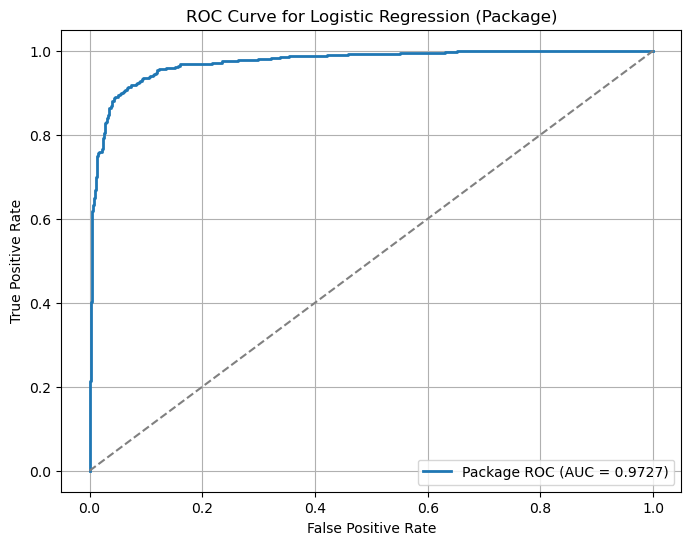


Manual ROC points
----------------------------------------
Threshold   FPR         TPR         
0.0         1.0000      1.0000      
0.1         0.3085      0.9802      
0.2         0.1650      0.9692      
0.3         0.1019      0.9339      
0.4         0.0660      0.9075      
0.5         0.0430      0.8833      
0.6         0.0344      0.8502      
0.7         0.0273      0.8062      
0.8         0.0158      0.7489      
0.9         0.0043      0.6189      
1.0         0.0000      0.0000      


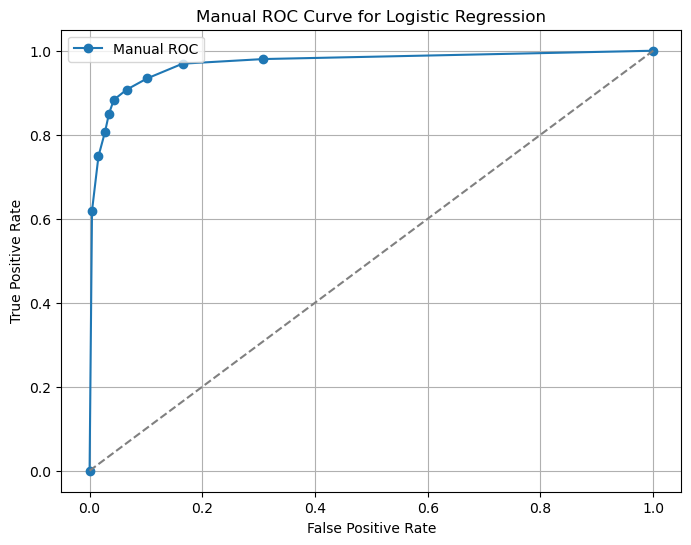

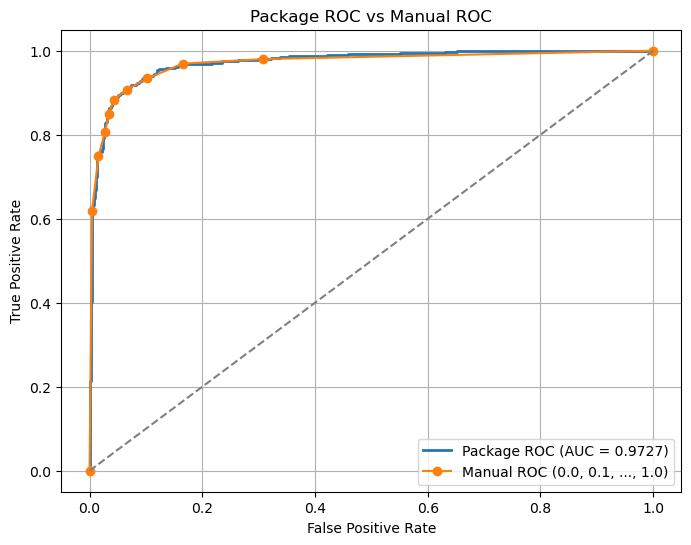

In [11]:
# Problem 3: Comparing classifiers on SPAMBASE
# ------------------------------------------------------------
# Trains Logistic Regression, LDA, and kNN
# Uses cross-validation to choose k for kNN
# Reports accuracy, error, precision, and recall on train/test
# Plots ROC curve for logistic regression using sklearn
# Plots ROC curve manually using thresholds {0, 0.1, ..., 1.0}
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score

# ------------------------------------------------------------
# 1. Load SPAMBASE data
# ------------------------------------------------------------
data = pd.read_csv("spambase.data", header=None)

X = data.iloc[:, :-1].values   # first 57 columns
y = data.iloc[:, -1].values    # last column: 1=spam, 0=ham

# ------------------------------------------------------------
# 2. Train/test split (same as Problem 1)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# ------------------------------------------------------------
# 3. Cross-validation to select k for kNN
#    Show accuracy, error, precision, recall for multiple k
#    Select k that minimizes average CV error
# ------------------------------------------------------------
k_values = [1, 3, 5, 7, 9, 11, 15, 21]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-validation results for kNN")
print("-" * 72)
print(f"{'k':<6}{'Accuracy':<12}{'Error':<12}{'Precision':<12}{'Recall':<12}")

cv_results = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_validate(
        knn_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall"]
    )

    mean_accuracy = np.mean(scores["test_accuracy"])
    mean_error = 1 - mean_accuracy
    mean_precision = np.mean(scores["test_precision"])
    mean_recall = np.mean(scores["test_recall"])

    cv_results.append((k, mean_accuracy, mean_error, mean_precision, mean_recall))

    print(f"{k:<6}{mean_accuracy:<12.4f}{mean_error:<12.4f}{mean_precision:<12.4f}{mean_recall:<12.4f}")

best_k = min(cv_results, key=lambda x: x[2])[0]
print("\nBest k selected by minimum average CV error:", best_k)

# ------------------------------------------------------------
# 4. Train all three classifiers
# ------------------------------------------------------------
log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=10000, random_state=42))
])

lda_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis())
])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

models = {
    "Logistic Regression": log_model,
    "LDA": lda_model,
    "kNN": knn_model
}

for model in models.values():
    model.fit(X_train, y_train)

# ------------------------------------------------------------
# 5. Evaluate accuracy, error, precision, recall on train/test
# ------------------------------------------------------------
def evaluate_classifier(model, X_data, y_data):
    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_data, y_pred)
    error = 1 - accuracy
    precision = precision_score(y_data, y_pred, zero_division=0)
    recall = recall_score(y_data, y_pred, zero_division=0)

    return accuracy, error, precision, recall

print("\nTraining and Testing Results")
print("-" * 90)
print(f"{'Model':<22}{'Dataset':<10}{'Accuracy':<12}{'Error':<12}{'Precision':<12}{'Recall':<12}")

for name, model in models.items():
    train_metrics = evaluate_classifier(model, X_train, y_train)
    test_metrics = evaluate_classifier(model, X_test, y_test)

    print(f"{name:<22}{'Train':<10}{train_metrics[0]:<12.4f}{train_metrics[1]:<12.4f}{train_metrics[2]:<12.4f}{train_metrics[3]:<12.4f}")
    print(f"{name:<22}{'Test':<10}{test_metrics[0]:<12.4f}{test_metrics[1]:<12.4f}{test_metrics[2]:<12.4f}{test_metrics[3]:<12.4f}")

# ------------------------------------------------------------
# 6. ROC curve for logistic regression using package
#    Compute AUC on testing set
# ------------------------------------------------------------
log_probs = log_model.predict_proba(X_test)[:, 1]

fpr_pkg, tpr_pkg, thresholds_pkg = roc_curve(y_test, log_probs)
auc_score = roc_auc_score(y_test, log_probs)

print("\nLogistic Regression AUC:", round(auc_score, 4))

plt.figure(figsize=(8, 6))
plt.plot(fpr_pkg, tpr_pkg, label=f"Package ROC (AUC = {auc_score:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Logistic Regression (Package)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 7. Manual ROC curve without package
#    Thresholds T in {0, 0.1, ..., 1.0}
# ------------------------------------------------------------
manual_thresholds = np.arange(0.0, 1.01, 0.1)

manual_fpr = []
manual_tpr = []

print("\nManual ROC points")
print("-" * 40)
print(f"{'Threshold':<12}{'FPR':<12}{'TPR':<12}")

for T in manual_thresholds:
    y_pred_manual = (log_probs >= T).astype(int)

    TP = np.sum((y_test == 1) & (y_pred_manual == 1))
    TN = np.sum((y_test == 0) & (y_pred_manual == 0))
    FP = np.sum((y_test == 0) & (y_pred_manual == 1))
    FN = np.sum((y_test == 1) & (y_pred_manual == 0))

    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0

    manual_tpr.append(tpr)
    manual_fpr.append(fpr)

    print(f"{T:<12.1f}{fpr:<12.4f}{tpr:<12.4f}")

plt.figure(figsize=(8, 6))
plt.plot(manual_fpr, manual_tpr, marker="o", label="Manual ROC")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve for Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 8. Plot package ROC and manual ROC together for comparison
# ------------------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(fpr_pkg, tpr_pkg, linewidth=2, label=f"Package ROC (AUC = {auc_score:.4f})")
plt.plot(manual_fpr, manual_tpr, marker="o", linestyle="-", label="Manual ROC (0.0, 0.1, ..., 1.0)")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Package ROC vs Manual ROC")
plt.legend()
plt.grid(True)
plt.show()?.oku